## 1. გარემოს მომზადება - Kaggle & მონაცემების ჩამოტვირთვა

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install kaggle
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [3]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
unzip:  cannot find or open walmart-recruiting-store-sales-forecasting.zip, walmart-recruiting-store-sales-forecasting.zip.zip or walmart-recruiting-store-sales-forecasting.zip.ZIP.


In [4]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 17.4 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [5]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [6]:
!kaggle datasets download -d aslanahmedov/walmart-sales-forecast


Dataset URL: https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
License(s): copyright-authors
100% 3.36M/3.36M [00:00<00:00, 243MB/s]



In [7]:
!unzip -o walmart-sales-forecast.zip -d data/


Archive:  walmart-sales-forecast.zip
  inflating: data/features.csv       
  inflating: data/stores.csv         
  inflating: data/test.csv           
  inflating: data/train.csv          


# მონაცემებზე პირველადი დაკვირვება

In [8]:
import pandas as pd
import numpy as np

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
features = pd.read_csv('data/features.csv')
stores = pd.read_csv('data/stores.csv')

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

train.head()

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [9]:
train.info()
print("\nMissing values (train):\n", train.isnull().sum())
print("\nMissing values (features):\n", features.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Missing values (train):
 Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Missing values (features):
 Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [10]:
!pip install -q dagshub mlflow==2.22.0 lightgbm shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

pd.set_option('display.max_columns', 50)

In [12]:
import dagshub
import mlflow

dagshub.init(
    repo_owner='aleko-mamukashvili',
    repo_name='Store-Sales-Forecasting',
    mlflow=True
)

EXPERIMENT_NAME = "LightGBM_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=8d2b3965-9ce0-4feb-9d77-72c669f3fbc7&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d8f3309ab06e06c2511fd8a57c6225f2196aef9f9514986094af5b0abc806ba8




Accessing as ndoda23

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

<Experiment: artifact_location='mlflow-artifacts:/03a42b7449f94cdca4242e697a49f897', creation_time=1783706126365, experiment_id='2', last_update_time=1783706126365, lifecycle_stage='active', name='LightGBM_Training', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [13]:
DATA_PATH = "data"

train_raw = pd.read_csv(f"{DATA_PATH}/train.csv")
features_raw = pd.read_csv(f"{DATA_PATH}/features.csv")
stores_raw = pd.read_csv(f"{DATA_PATH}/stores.csv")

df = train_raw.merge(features_raw, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
df = df.merge(stores_raw, on='Store', how='left')

if 'IsHoliday_feat' in df.columns:
    df = df.drop(columns=['IsHoliday_feat'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# EDA - გადაწყვეტილებები მონაცემებზე დაყრდნობით

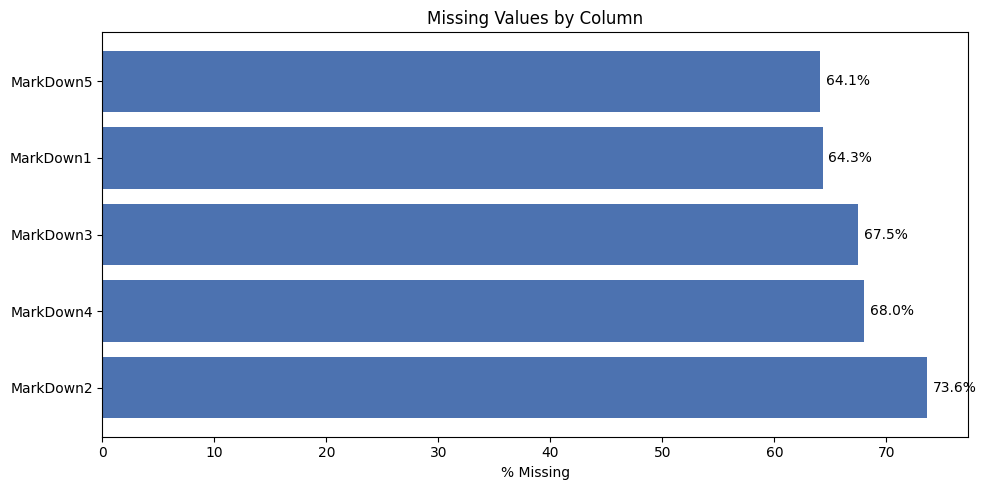

MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64


In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing.index, missing_pct.values, color='#4C72B0')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

print(missing)

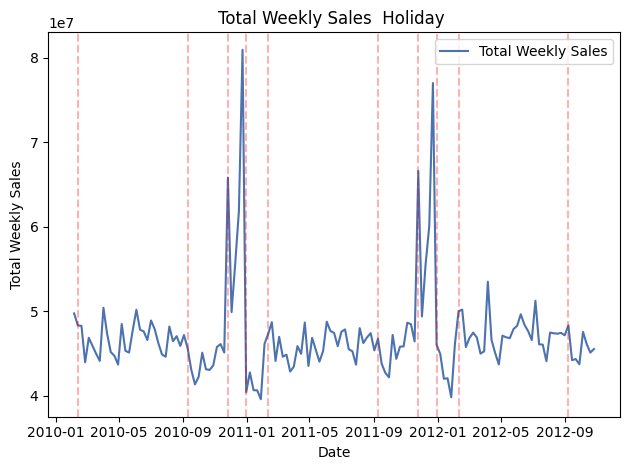

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow


weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
holiday_dates = df[df['IsHoliday']]['Date'].unique()

fig, ax = plt.subplots()
ax.plot(weekly_total.index, weekly_total.values, color='#4C72B0', label='Total Weekly Sales')
for hd in holiday_dates:
    ax.axvline(pd.Timestamp(hd), color='red', alpha=0.3, linestyle='--')
ax.set_title('Total Weekly Sales  Holiday ')
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales')
ax.legend()
plt.tight_layout()
plt.show()

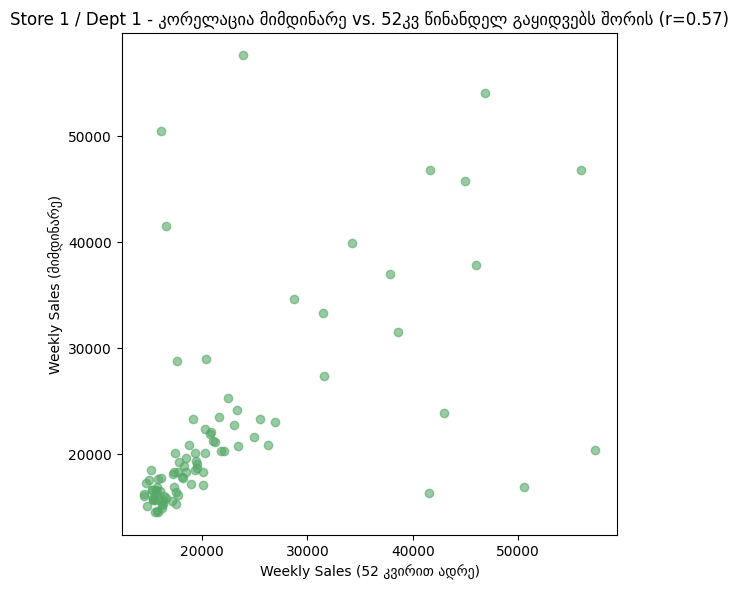

Pearson r (52-week lag) store1/dept1: 0.573


In [16]:
sample = df[(df['Store'] == 1) & (df['Dept'] == 1)].set_index('Date')['Weekly_Sales']
sample_shifted = sample.shift(freq=pd.Timedelta(weeks=52))

merged_lag_check = pd.DataFrame({
    'current': sample,
    'same_week_last_year': sample_shifted
}).dropna()

corr = merged_lag_check['current'].corr(merged_lag_check['same_week_last_year'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged_lag_check['same_week_last_year'], merged_lag_check['current'], alpha=0.6, color='#55A868')
ax.set_xlabel('Weekly Sales (52 კვირით ადრე)')
ax.set_ylabel('Weekly Sales (მიმდინარე)')
ax.set_title(f'Store 1 / Dept 1 - კორელაცია მიმდინარე vs. 52კვ წინანდელ გაყიდვებს შორის (r={corr:.2f})')
plt.tight_layout()
plt.show()

print(f"Pearson r (52-week lag) store1/dept1: {corr:.3f}")

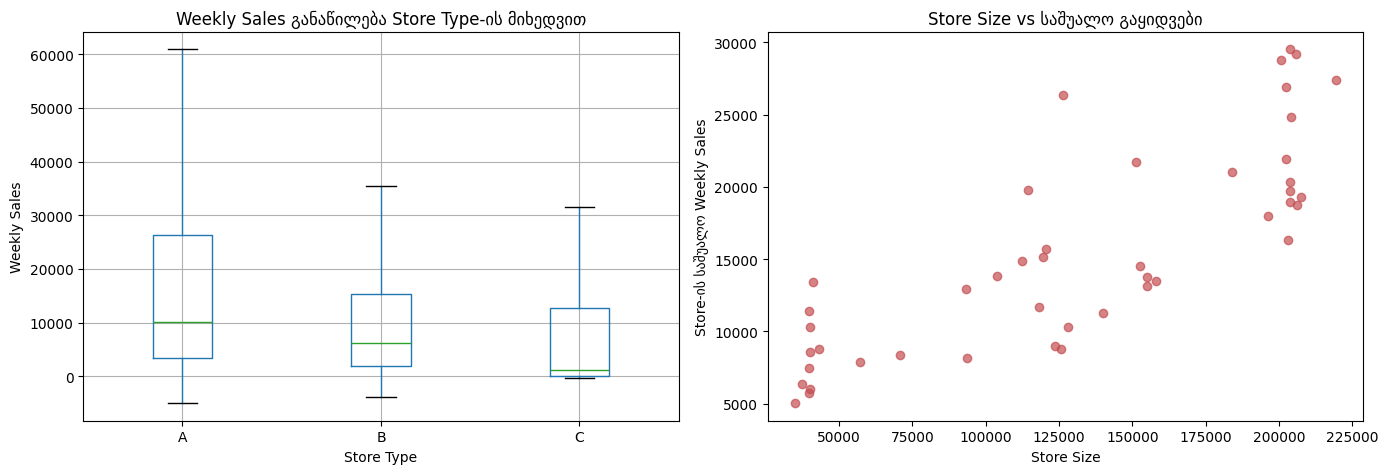

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Weekly_Sales', by='Type', ax=axes[0], showfliers=False)
axes[0].set_title('Weekly Sales განაწილება Store Type-ის მიხედვით')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Weekly Sales')

axes[1].scatter(stores_raw['Size'], stores_raw.merge(
    df.groupby('Store')['Weekly_Sales'].mean().reset_index(), on='Store'
)['Weekly_Sales'], alpha=0.7, color='#C44E52')
axes[1].set_xlabel('Store Size')
axes[1].set_ylabel('Store-ის საშუალო Weekly Sales')
axes[1].set_title('Store Size vs საშუალო გაყიდვები')

plt.suptitle('')
plt.tight_layout()
plt.show()

# კორელაციები

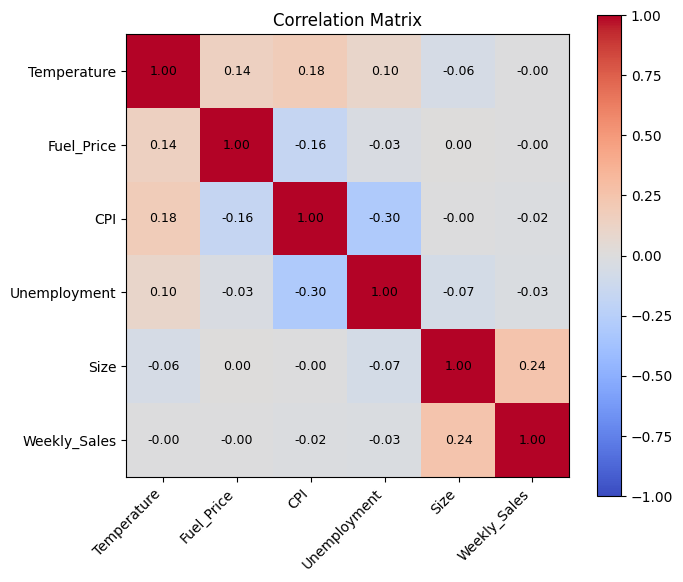

In [18]:
numeric_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Weekly_Sales']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

# მონაცემების გაყოფა TRAIN/VALIDATION

In [19]:
naive_split = df['Date'].max() - pd.Timedelta(weeks=12)
naive_val = df[df['Date'] > naive_split]
print("Naive val window:", naive_val['Date'].min().date(), "->", naive_val['Date'].max().date())
print("Holiday კვირები naive val-ში:", sorted(naive_val[naive_val['IsHoliday']]['Date'].dt.date.unique()))
print()

holiday_val_start = pd.Timestamp('2011-11-01')
holiday_val_end = pd.Timestamp('2012-02-15')
holiday_val = df[(df['Date'] >= holiday_val_start) & (df['Date'] <= holiday_val_end)]
print("Holiday-inclusive val window:", holiday_val['Date'].min().date(), "->", holiday_val['Date'].max().date())
print("Holiday კვირები ამ val-ში:", sorted(holiday_val[holiday_val['IsHoliday']]['Date'].dt.date.unique()))

Naive val window: 2012-08-10 -> 2012-10-26
Holiday კვირები naive val-ში: [datetime.date(2012, 9, 7)]

Holiday-inclusive val window: 2011-11-04 -> 2012-02-10
Holiday კვირები ამ val-ში: [datetime.date(2011, 11, 25), datetime.date(2011, 12, 30), datetime.date(2012, 2, 10)]


In [20]:
VAL_START = pd.Timestamp('2011-11-01')
VAL_END = pd.Timestamp('2012-02-15')

train_df = df[df['Date'] < VAL_START].copy()
val_df = df[(df['Date'] >= VAL_START) & (df['Date'] <= VAL_END)].copy()

print(f"Train: {train_df.shape} | {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}")
print(f"Val:   {val_df.shape} | {val_df['Date'].min().date()} -> {val_df['Date'].max().date()}")
print(f"Holiday კვირები val-ში: {sorted(val_df[val_df['IsHoliday']]['Date'].dt.date.unique())}")

X_train, y_train = train_df.drop(columns=['Weekly_Sales']), train_df['Weekly_Sales']
X_val, y_val = val_df.drop(columns=['Weekly_Sales']), val_df['Weekly_Sales']

Train: (267184, 16) | 2010-02-05 -> 2011-10-28
Val:   (44776, 16) | 2011-11-04 -> 2012-02-10
Holiday კვირები val-ში: [datetime.date(2011, 11, 25), datetime.date(2011, 12, 30), datetime.date(2012, 2, 10)]


# Feture Engineering

In [21]:
class LagFeatureBuilder(BaseEstimator, TransformerMixin):

    def __init__(self, lag_weeks=(51, 52, 53)):
        self.lag_weeks = lag_weeks

    def fit(self, X, y):
        hist = X[['Store', 'Dept', 'Date']].copy()
        hist['Weekly_Sales'] = np.asarray(y)
        self.history_ = hist.drop_duplicates(subset=['Store', 'Dept', 'Date'])
        return self

    def transform(self, X):
        X = X.copy()
        for w in self.lag_weeks:
            shifted = self.history_.copy()
            shifted['Date'] = shifted['Date'] + pd.Timedelta(weeks=w)
            shifted = shifted.rename(columns={'Weekly_Sales': f'Sales_Lag_{w}w'})
            X = X.merge(shifted[['Store', 'Dept', 'Date', f'Sales_Lag_{w}w']],
                        on=['Store', 'Dept', 'Date'], how='left')
        return X

In [22]:
class GroupStatsFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        tmp = X[['Store', 'Dept']].copy()
        tmp['Weekly_Sales'] = np.asarray(y)
        self.group_stats_ = (
            tmp.groupby(['Store', 'Dept'])['Weekly_Sales']
               .agg(Group_Mean='mean', Group_Median='median', Group_Std='std')
               .reset_index()
        )
        return self

    def transform(self, X):
        return X.merge(self.group_stats_, on=['Store', 'Dept'], how='left')

In [23]:
class TemporalFeatureBuilder(BaseEstimator, TransformerMixin):
    TYPE_MAP = {'A': 0, 'B': 1, 'C': 2}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X['IsHoliday'] = X['IsHoliday'].astype(int)
        X['Type'] = X['Type'].map(self.TYPE_MAP)
        X = X.drop(columns=['Date'])
        return X

In [24]:
class LGBMFinalEstimator(BaseEstimator, RegressorMixin):
    """LightGBM wrapper — pipeline-ის ბოლო step, რომ preprocessing+model ერთ obj-ად ინახებოდეს."""
    def __init__(self, learning_rate=0.05, num_boost_round=300, max_depth=-1,
                 objective='mae', random_state=42):
        self.learning_rate = learning_rate
        self.num_boost_round = num_boost_round
        self.max_depth = max_depth
        self.objective = objective
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        self.feature_cols_ = list(X.columns)
        train_set = lgb.Dataset(X[self.feature_cols_], label=y, weight=sample_weight)
        params = {
            'learning_rate': self.learning_rate,
            'max_depth': self.max_depth,
            'objective': self.objective,
            'random_state': self.random_state,
            'deterministic': True,
            'verbosity': -1,
        }
        self.booster_ = lgb.train(params, train_set, num_boost_round=self.num_boost_round)
        return self

    def predict(self, X):
        return self.booster_.predict(X[self.feature_cols_])

# დამატებითი Feature Engineering ვარიანტები

In [ ]:
class MissingValueHandler(BaseEstimator, TransformerMixin):
    MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.MARKDOWN_COLS:
            if c in X.columns:
                X[c] = X[c].fillna(0)
        for c in ['CPI', 'Unemployment']:
            if c in X.columns:
                X[c] = X.groupby('Store')[c].transform(lambda s: s.ffill().bfill())
        return X

In [ ]:
class RollingFeatureBuilder(BaseEstimator, TransformerMixin):

    def __init__(self, windows=(4, 8)):
        self.windows = windows

    def fit(self, X, y):
        hist = X[['Store', 'Dept', 'Date']].copy()
        hist['Weekly_Sales'] = np.asarray(y)
        self.history_ = hist.sort_values(['Store', 'Dept', 'Date'])
        return self

    def transform(self, X):
        h = self.history_.copy()
        for w in self.windows:
            h[f'Rolling_Mean_{w}w'] = (
                h.groupby(['Store', 'Dept'])['Weekly_Sales']
                 .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
            )
            h[f'Rolling_Std_{w}w'] = (
                h.groupby(['Store', 'Dept'])['Weekly_Sales']
                 .transform(lambda s: s.shift(1).rolling(w, min_periods=1).std())
            )
        roll_cols = [c for c in h.columns if c.startswith('Rolling_')]
        return X.merge(h[['Store', 'Dept', 'Date'] + roll_cols], on=['Store', 'Dept', 'Date'], how='left')

In [ ]:
class TotalMarkDownBuilder(BaseEstimator, TransformerMixin):
    """5 ცალკეული MarkDown სვეტის ნაცვლად - ერთი ჯამური feature. მარტივია, შესაძლოა ცოტა ინფორმაციას კარგავს."""
    MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        present = [c for c in self.MARKDOWN_COLS if c in X.columns]
        X['Total_MarkDown'] = X[present].fillna(0).sum(axis=1)
        X = X.drop(columns=present)
        return X

In [ ]:
class TemporalFeatureBuilderOneHot(BaseEstimator, TransformerMixin):
    """იგივე რაც TemporalFeatureBuilder, მაგრამ Type-ს one-hot-ავს ordinal-ის ნაცვლად."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X['IsHoliday'] = X['IsHoliday'].astype(int)
        X = pd.get_dummies(X, columns=['Type'], prefix='Type')
        X = X.drop(columns=['Date'])
        return X

In [39]:
class DropWeakFeatures(BaseEstimator, TransformerMixin):
    WEAK_COLS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.WEAK_COLS if c in X.columns])

# მეტრიკები, შეფასება და MlFlow logging helper ები

In [25]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(np.asarray(y_true) - y_pred)) / np.sum(weights)

def evaluate(pipeline, X_tr, y_tr, X_v, y_v):
    pred_tr = pipeline.predict(X_tr)
    pred_v = pipeline.predict(X_v)
    return {
        'mae_train': mean_absolute_error(y_tr, pred_tr),
        'mae_val': mean_absolute_error(y_v, pred_v),
        'wmae_train': wmae(y_tr, pred_tr, X_tr['IsHoliday']),
        'wmae_val': wmae(y_v, pred_v, X_v['IsHoliday']),
    }

def plot_actual_vs_pred(pipeline, train_df_raw, val_df_raw, X_tr, X_v, title):
    pred_tr = pipeline.predict(X_tr)
    pred_v = pipeline.predict(X_v)

    tr_agg = train_df_raw.groupby('Date')['Weekly_Sales'].mean()
    val_agg = val_df_raw.groupby('Date')['Weekly_Sales'].mean()
    pred_tr_agg = pd.DataFrame({'Date': train_df_raw['Date'], 'pred': pred_tr}).groupby('Date')['pred'].mean()
    pred_val_agg = pd.DataFrame({'Date': val_df_raw['Date'], 'pred': pred_v}).groupby('Date')['pred'].mean()

    fig, ax = plt.subplots()
    ax.plot(tr_agg.index, tr_agg.values, color='#4C72B0', label='Actual (Train)')
    ax.plot(val_agg.index, val_agg.values, color='#C44E52', label='Actual (Val)')
    ax.plot(pred_tr_agg.index, pred_tr_agg.values, color='#4C72B0', linestyle='--', alpha=0.6, label='Predicted (Train)')
    ax.plot(pred_val_agg.index, pred_val_agg.values, color='#C44E52', linestyle='--', alpha=0.9, label='Predicted (Val)')
    ax.axvline(train_df_raw['Date'].max(), color='gray', linestyle=':', label='Train/Val Split')
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Average Weekly Sales')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [26]:
def log_run(run_name, params, metrics, pipeline=None, registered_name=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if pipeline is not None:
            mlflow.sklearn.log_model(
                pipeline, "model",
                registered_model_name=registered_name
            )
        print(run_name, "->", metrics)

In [29]:
experiment_log = []

def run_experiment(name, pipeline_steps, X_tr=X_train, y_tr=y_train, X_v=X_val, y_v=y_val,
                    sample_weight=None, registered_name=None, notes=""):
    pipe = Pipeline(pipeline_steps)
    if sample_weight is not None:
        pipe.fit(X_tr, y_tr, model__sample_weight=sample_weight)
    else:
        pipe.fit(X_tr, y_tr)
    m = evaluate(pipe, X_tr, y_tr, X_v, y_v)
    experiment_log.append({'run': name, **m, 'notes': notes})
    log_run(name, params={'notes': notes}, metrics=m, pipeline=pipe, registered_name=registered_name)
    return pipe, m

# ექსპერიმენტები და Mlflow ში დალოგვა

# RUN1 - Baseline

In [27]:
sample_weight_train = np.where(X_train['IsHoliday'], 5, 1)

baseline_pipeline = Pipeline([
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
])

baseline_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)
baseline_metrics = evaluate(baseline_pipeline, X_train, y_train, X_val, y_val)
print(baseline_metrics)

{'mae_train': 3982.0094406328503, 'mae_val': 5487.976089467217, 'wmae_train': np.float64(4146.063409141717), 'wmae_val': np.float64(5893.293616120078)}


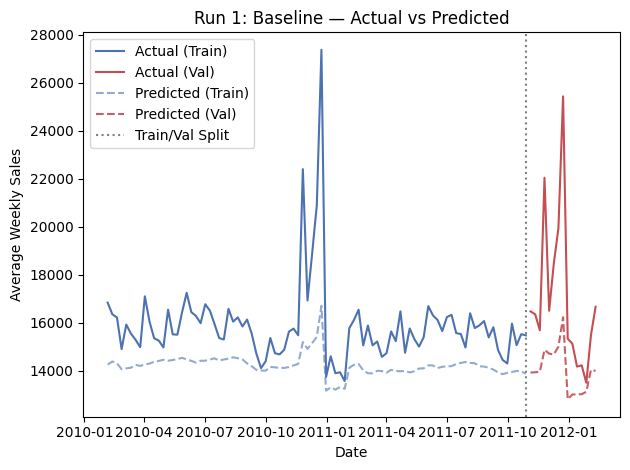

In [ ]:
plot_actual_vs_pred(baseline_pipeline, train_df, val_df, X_train, X_val,
                     'Run 1: Baseline — Actual vs Predicted')

In [ ]:
log_run(
    "LightGBM_Baseline",
    params={'features': 'temporal_only', 'learning_rate': 0.1, 'num_boost_round': 150},
    metrics=baseline_metrics,
    pipeline=baseline_pipeline,
)

2026/07/10 19:12:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_Baseline -> {'mae_train': 3982.0094406328503, 'mae_val': 5487.976089467217, 'wmae_train': np.float64(4146.063409141717), 'wmae_val': np.float64(5893.293616120078)}
🏃 View run LightGBM_Baseline at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/6e7b5c17430a4f1b808111f528984fa8
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2


# RUN2 - Lag Features

In [ ]:
lag_pipeline = Pipeline([
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
])

lag_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)
lag_metrics = evaluate(lag_pipeline, X_train, y_train, X_val, y_val)
print(lag_metrics)

{'mae_train': 3443.045370966616, 'mae_val': 2385.3367468923793, 'wmae_train': np.float64(3635.8759395032325), 'wmae_val': np.float64(2651.8688457567005)}


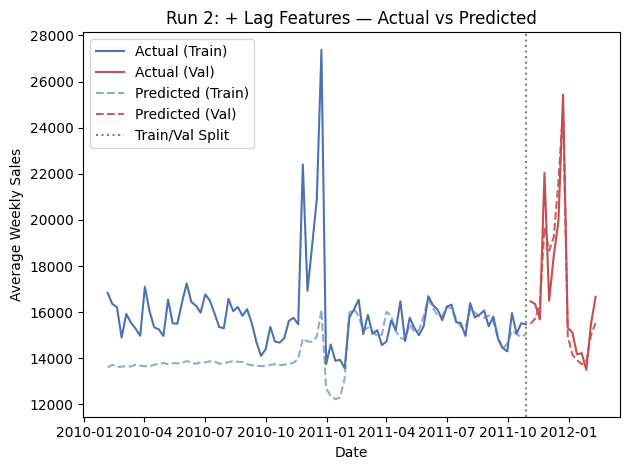

In [ ]:
plot_actual_vs_pred(lag_pipeline, train_df, val_df, X_train, X_val,
                     'Run 2: + Lag Features — Actual vs Predicted')

In [ ]:
log_run(
    "LightGBM_LagFeatures",
    params={'features': 'temporal+lags', 'lag_weeks': '51,52,53', 'learning_rate': 0.1, 'num_boost_round': 150},
    metrics=lag_metrics,
    pipeline=lag_pipeline,
)

2026/07/10 19:17:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_LagFeatures -> {'mae_train': 3443.045370966616, 'mae_val': 2385.3367468923793, 'wmae_train': np.float64(3635.8759395032325), 'wmae_val': np.float64(2651.8688457567005)}
🏃 View run LightGBM_LagFeatures at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/38cc204b60114f2286681995ca0c1ebd
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2


# RUN3 - Group Statistics Features

In [31]:
full_pipeline = Pipeline([
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
])

full_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)
full_metrics = evaluate(full_pipeline, X_train, y_train, X_val, y_val)
print(full_metrics)

{'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


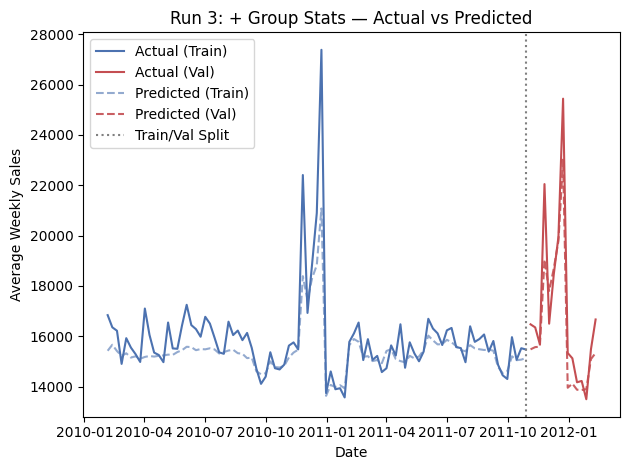

In [ ]:
plot_actual_vs_pred(full_pipeline, train_df, val_df, X_train, X_val,
                     'Run 3: + Group Stats — Actual vs Predicted')

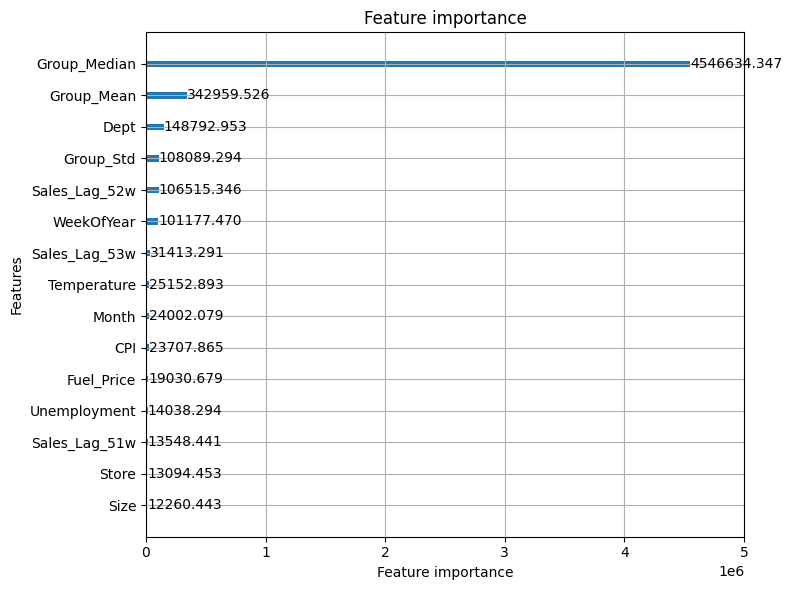

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(full_pipeline.named_steps['model'].booster_, importance_type='gain',
                     max_num_features=15, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
log_run(
    "LightGBM_LagAndGroupFeatures",
    params={'features': 'temporal+lags+group_stats', 'learning_rate': 0.1, 'num_boost_round': 150},
    metrics=full_metrics,
    pipeline=full_pipeline,
)

2026/07/10 19:26:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_LagAndGroupFeatures -> {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}
🏃 View run LightGBM_LagAndGroupFeatures at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/6b25b0d6e8b34c1d96c20178f3205b59
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2


# Cross-Validation(Rolling window,3 fold)

In [ ]:
def rolling_cv_folds(df, n_folds=3, val_weeks=8):
    max_date = df['Date'].max()
    folds = []
    for i in range(n_folds, 0, -1):
        fold_val_end = max_date - pd.Timedelta(weeks=val_weeks * (i - 1))
        fold_val_start = fold_val_end - pd.Timedelta(weeks=val_weeks)
        fold_train_end = fold_val_start
        folds.append((fold_train_end, fold_val_start, fold_val_end))
    return folds

cv_folds = rolling_cv_folds(train_df, n_folds=3, val_weeks=8)
cv_wmae_scores = []

for fold_i, (train_end, val_start, val_end) in enumerate(cv_folds, start=1):
    fold_train = df[df['Date'] <= train_end]
    fold_val = df[(df['Date'] > val_start) & (df['Date'] <= val_end)]

    Xf_tr, yf_tr = fold_train.drop(columns=['Weekly_Sales']), fold_train['Weekly_Sales']
    Xf_v, yf_v = fold_val.drop(columns=['Weekly_Sales']), fold_val['Weekly_Sales']
    w_tr = np.where(Xf_tr['IsHoliday'], 5, 1)

    fold_pipeline = Pipeline([
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ])
    fold_pipeline.fit(Xf_tr, yf_tr, model__sample_weight=w_tr)
    pred_v = fold_pipeline.predict(Xf_v)
    fold_wmae = wmae(yf_v, pred_v, Xf_v['IsHoliday'])
    cv_wmae_scores.append(fold_wmae)
    print(f"Fold {fold_i}: train_end={train_end.date()} val=({val_start.date()}, {val_end.date()}] -> WMAE={fold_wmae:.2f}")

cv_metrics = {
    'wmae_cv_mean': float(np.mean(cv_wmae_scores)),
    'wmae_cv_std': float(np.std(cv_wmae_scores)),
}
print(cv_metrics)

Fold 1: train_end=2011-05-13 val=(2011-05-13, 2011-07-08] -> WMAE=1932.41


KeyboardInterrupt: 

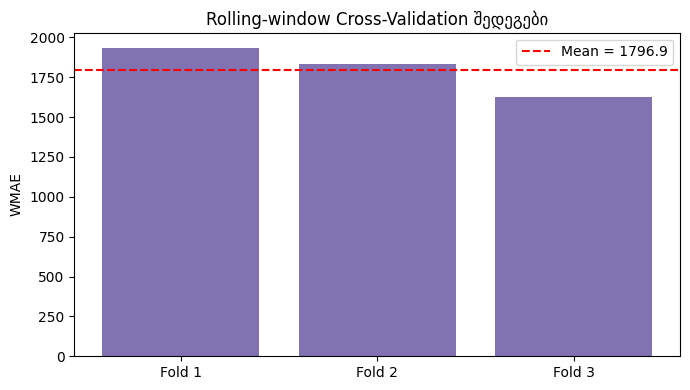

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f'Fold {i+1}' for i in range(len(cv_wmae_scores))], cv_wmae_scores, color='#8172B2')
ax.axhline(np.mean(cv_wmae_scores), color='red', linestyle='--', label=f'Mean = {np.mean(cv_wmae_scores):.1f}')
ax.set_ylabel('WMAE')
ax.set_title('Rolling-window Cross-Validation შედეგები')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
log_run(
    "LightGBM_CrossValidation",
    params={'n_folds': 3, 'val_weeks': 8, 'features': 'temporal+lags+group_stats'},
    metrics=cv_metrics,
    pipeline=None,
)

LightGBM_CrossValidation -> {'wmae_cv_mean': 1796.896610392281, 'wmae_cv_std': 128.29074306246696}
🏃 View run LightGBM_CrossValidation at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/3539dfd265544a5dbdc6f47fa109ee8e
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2


# Hyperparameter Search

In [35]:
hp_grid = [
    {'learning_rate': 0.05, 'num_boost_round': 300, 'max_depth': -1},
    {'learning_rate': 0.05, 'num_boost_round': 300, 'max_depth': 6},
    {'learning_rate': 0.03, 'num_boost_round': 500, 'max_depth': 8},
]

hp_results = []

for params in hp_grid:
    pipe = Pipeline([
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(objective='mae', random_state=42, **params)),
    ])
    pipe.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    m = evaluate(pipe, X_train, y_train, X_val, y_val)
    print(params, '->', m)
    hp_results.append((params, m, pipe))

{'learning_rate': 0.05, 'num_boost_round': 300, 'max_depth': -1} -> {'mae_train': 1912.0712686095242, 'mae_val': 2704.8388110687933, 'wmae_train': np.float64(2077.077089317224), 'wmae_val': np.float64(3095.4822716111867)}
{'learning_rate': 0.05, 'num_boost_round': 300, 'max_depth': 6} -> {'mae_train': 1977.1067875543288, 'mae_val': 2676.6303592376685, 'wmae_train': np.float64(2166.974010677256), 'wmae_val': np.float64(3083.53422872642)}
{'learning_rate': 0.03, 'num_boost_round': 500, 'max_depth': 8} -> {'mae_train': 1949.660605596369, 'mae_val': 2689.723173352103, 'wmae_train': np.float64(2127.97279891495), 'wmae_val': np.float64(3123.3916141550835)}


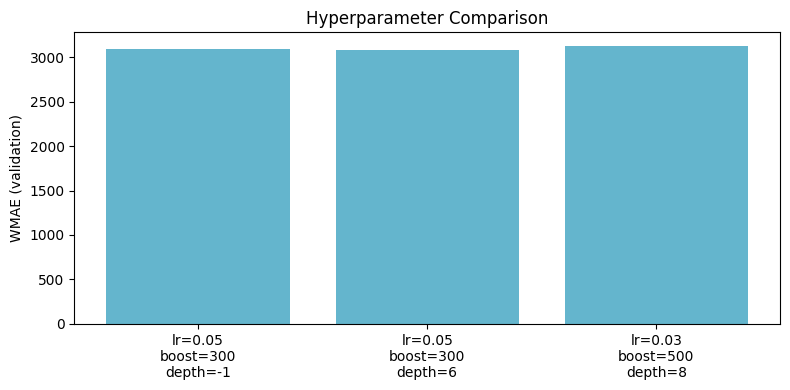

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"lr={p['learning_rate']}\nboost={p['num_boost_round']}\ndepth={p['max_depth']}" for p, m, _ in hp_results]
scores = [m['wmae_val'] for p, m, _ in hp_results]
ax.bar(labels, scores, color='#64B5CD')
ax.set_ylabel('WMAE (validation)')
ax.set_title('Hyperparameter Comparison')
plt.tight_layout()
plt.show()

In [36]:
for params, m, pipe in hp_results:
    run_name = f"LightGBM_HPO_lr{params['learning_rate']}_depth{params['max_depth']}"
    log_run(run_name, params=params, metrics=m, pipeline=pipe)

best_params, best_metrics, best_pipeline = min(hp_results, key=lambda r: r[1]['wmae_val'])
print("საუკეთესო კონფიგურაცია:", best_params, best_metrics)

2026/07/11 05:19:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_HPO_lr0.05_depth-1 -> {'mae_train': 1912.0712686095242, 'mae_val': 2704.8388110687933, 'wmae_train': np.float64(2077.077089317224), 'wmae_val': np.float64(3095.4822716111867)}
🏃 View run LightGBM_HPO_lr0.05_depth-1 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/501f87864ab84c7b8c573be63ac5cd0b
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2


2026/07/11 05:19:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_HPO_lr0.05_depth6 -> {'mae_train': 1977.1067875543288, 'mae_val': 2676.6303592376685, 'wmae_train': np.float64(2166.974010677256), 'wmae_val': np.float64(3083.53422872642)}
🏃 View run LightGBM_HPO_lr0.05_depth6 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/26bd8d5f6c774195a047f2bce3096371
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2


2026/07/11 05:19:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_HPO_lr0.03_depth8 -> {'mae_train': 1949.660605596369, 'mae_val': 2689.723173352103, 'wmae_train': np.float64(2127.97279891495), 'wmae_val': np.float64(3123.3916141550835)}
🏃 View run LightGBM_HPO_lr0.03_depth8 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/3b2c79895df64289a10541a422390e67
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
საუკეთესო კონფიგურაცია: {'learning_rate': 0.05, 'num_boost_round': 300, 'max_depth': 6} {'mae_train': 1977.1067875543288, 'mae_val': 2676.6303592376685, 'wmae_train': np.float64(2166.974010677256), 'wmae_val': np.float64(3083.53422872642)}


# დამატებითი ექსპერიმენტები Ablations,Control,Sanity checks

In [ ]:
imputed_pipeline, imputed_metrics = run_experiment(
    "LightGBM_ExplicitImputation",
    [
        ('impute', MissingValueHandler()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    sample_weight=sample_weight_train,
    notes="MarkDown NaN->0, CPI/Unemployment ffill (vs LightGBM native NaN handling)",
)
print("Explicit imputation:", imputed_metrics)
print("(შედარებისთვის) native NaN handling (Run 3):", full_metrics)

2026/07/10 19:55:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_ExplicitImputation -> {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}
🏃 View run LightGBM_ExplicitImputation at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/aba279c6c1f64bfd814ef42d7c912883
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
Explicit imputation: {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}
(შედარებისთვის) native NaN handling (Run 3): {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


In [ ]:
_, rolling_metrics = run_experiment(
    "LightGBM_RollingFeatures",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('rolling', RollingFeatureBuilder(windows=(4, 8))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    sample_weight=sample_weight_train,
    notes="lag + rolling(4w,8w) mean/std + group stats",
)
print(rolling_metrics)

2026/07/10 19:59:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_RollingFeatures -> {'mae_train': 1630.3504728922412, 'mae_val': 4070.618929497197, 'wmae_train': np.float64(1784.5886964987162), 'wmae_val': np.float64(4389.529792560894)}
🏃 View run LightGBM_RollingFeatures at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/e257c873751c40f6bc3ee5c6323bb923
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 1630.3504728922412, 'mae_val': 4070.618929497197, 'wmae_train': np.float64(1784.5886964987162), 'wmae_val': np.float64(4389.529792560894)}


In [ ]:
_, totalmd_metrics = run_experiment(
    "LightGBM_TotalMarkDown",
    [
        ('total_markdown', TotalMarkDownBuilder()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    sample_weight=sample_weight_train,
    notes="5 ცალკეული MarkDown სვეტის ნაცვლად 1 ჯამური",
)
print(totalmd_metrics)

2026/07/10 22:15:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_TotalMarkDown -> {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}
🏃 View run LightGBM_TotalMarkDown at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/1ea61d0fe76047f7beed7a3c9d66fa16
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


# One hot encoding

In [ ]:
_, onehot_metrics = run_experiment(
    "LightGBM_TypeOneHot",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilderOneHot()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    sample_weight=sample_weight_train,
    notes="Store Type: one-hot ordinal-ის ნაცვლად",
)
print(onehot_metrics)

2026/07/10 22:18:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_TypeOneHot -> {'mae_train': 1889.43060579155, 'mae_val': 2646.0886068522877, 'wmae_train': np.float64(2029.4312589395267), 'wmae_val': np.float64(2998.6014636110676)}
🏃 View run LightGBM_TypeOneHot at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/a8bb5e49602c4bf28c98af0588ed6624
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 1889.43060579155, 'mae_val': 2646.0886068522877, 'wmae_train': np.float64(2029.4312589395267), 'wmae_val': np.float64(2998.6014636110676)}


# Log-Transform Target

In [ ]:
def signed_log1p(y):
    return np.sign(y) * np.log1p(np.abs(y))

def signed_expm1(y):
    return np.sign(y) * (np.expm1(np.abs(y)))

y_train_log = signed_log1p(y_train)

log_pipeline = Pipeline([
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
])
log_pipeline.fit(X_train, y_train_log, model__sample_weight=sample_weight_train)

pred_val_log = log_pipeline.predict(X_val)
pred_val_original_scale = signed_expm1(pred_val_log)

log_wmae_val = wmae(y_val, pred_val_original_scale, X_val['IsHoliday'])
log_metrics = {'wmae_val': log_wmae_val}
experiment_log.append({'run': 'LightGBM_LogTarget', **log_metrics, 'notes': 'signed-log1p target transform'})
print("Log-transform target WMAE (val, original scale):", log_wmae_val)
print("(შედარებისთვის) raw-scale target WMAE (Run 3):", full_metrics['wmae_val'])

Log-transform target WMAE (val, original scale): 2845.670630874069
(შედარებისთვის) raw-scale target WMAE (Run 3): 2830.9763101249855


# Feature Selection - სუსტი გარე featureბის მოცილება

In [40]:
_, dropweak_metrics = run_experiment(
    "LightGBM_DropWeakExternalFeatures",
    [
        ('drop_weak', DropWeakFeatures()),
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    sample_weight=sample_weight_train,
    notes="Temperature/Fuel_Price/CPI/Unemployment",
)
print(dropweak_metrics)
print("(შედარებისთვის) სრული feature-set (Run 3):", full_metrics)

2026/07/11 05:21:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_DropWeakExternalFeatures -> {'mae_train': 1868.702464571675, 'mae_val': 2511.5269887297522, 'wmae_train': np.float64(1983.7021532413305), 'wmae_val': np.float64(2746.538026171567)}
🏃 View run LightGBM_DropWeakExternalFeatures at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/826712858ad449af9956be6aa062a4a4
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 1868.702464571675, 'mae_val': 2511.5269887297522, 'wmae_train': np.float64(1983.7021532413305), 'wmae_val': np.float64(2746.538026171567)}
(შედარებისთვის) სრული feature-set (Run 3): {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


# Control - Unweighted Training

In [ ]:
_, unweighted_metrics = run_experiment(
    "LightGBM_UnweightedControl",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    sample_weight=None,
    notes="CONTROL: სავალდებულო sample_weight=None, holiday-ების გარეშე წონა",
)
print("Unweighted:", unweighted_metrics)
print("(შედარებისთვის) weighted (Run 3):", full_metrics)

2026/07/10 22:20:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_UnweightedControl -> {'mae_train': 1868.4268249708668, 'mae_val': 2683.6031140277773, 'wmae_train': np.float64(2082.23767303531), 'wmae_val': np.float64(3123.5617381829857)}
🏃 View run LightGBM_UnweightedControl at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/a2b50b7fefd743148ac1d881bee0954f
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
Unweighted: {'mae_train': 1868.4268249708668, 'mae_val': 2683.6031140277773, 'wmae_train': np.float64(2082.23767303531), 'wmae_val': np.float64(3123.5617381829857)}
(შედარებისთვის) weighted (Run 3): {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


# Sanity check - Shuffled Target

In [ ]:
rng = np.random.RandomState(42)
y_train_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)

_, shuffled_metrics = run_experiment(
    "LightGBM_ShuffledTarget_SanityCheck",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    y_tr=y_train_shuffled,
    sample_weight=sample_weight_train,
    notes="SANITY CHECK: y_train შემთხვევითად არეულია — მოდელს არაფრის სწავლა არ უნდა შეეძლოს",
)
print("Shuffled-target (უნდა იყოს ცუდი):", shuffled_metrics)
print("(შედარებისთვის) ნამდვილი target (Run 3):", full_metrics)

2026/07/10 22:24:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_ShuffledTarget_SanityCheck -> {'mae_train': 13073.650464962628, 'mae_val': 14538.198325779442, 'wmae_train': np.float64(12950.683647754457), 'wmae_val': np.float64(14909.638744373058)}
🏃 View run LightGBM_ShuffledTarget_SanityCheck at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/d0d87ac1cd13404aab53d00bdb20e728
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
Shuffled-target (უნდა იყოს ცუდი): {'mae_train': 13073.650464962628, 'mae_val': 14538.198325779442, 'wmae_train': np.float64(12950.683647754457), 'wmae_val': np.float64(14909.638744373058)}
(შედარებისთვის) ნამდვილი target (Run 3): {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


# 5% იანი მონაცემ

In [ ]:
X_tiny = X_train.sample(frac=0.05, random_state=42)
y_tiny = y_train.loc[X_tiny.index]
w_tiny = np.where(X_tiny['IsHoliday'], 5, 1)

_, tiny_metrics = run_experiment(
    "LightGBM_Silly_5PercentData",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
    ],
    X_tr=X_tiny, y_tr=y_tiny,
    sample_weight=w_tiny,
    notes="სისულელე: train data-ის მხოლოდ 5% (random sample) — რამდენად მნიშვნელოვანია data-ის რაოდენობა?",
)
print(tiny_metrics)
print("(შედარებისთვის) სრული train data (Run 3):", full_metrics)

2026/07/10 22:25:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_Silly_5PercentData -> {'mae_train': 1828.5617321538462, 'mae_val': 4207.9031620979895, 'wmae_train': np.float64(1889.3254757631066), 'wmae_val': np.float64(4705.869173913015)}
🏃 View run LightGBM_Silly_5PercentData at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/9a11c78f77054b8199ea46f7aad4a328
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 1828.5617321538462, 'mae_val': 4207.9031620979895, 'wmae_train': np.float64(1889.3254757631066), 'wmae_val': np.float64(4705.869173913015)}
(შედარებისთვის) სრული train data (Run 3): {'mae_train': 1858.6522814287414, 'mae_val': 2559.133254644065, 'wmae_train': np.float64(1983.544299750891), 'wmae_val': np.float64(2830.9763101249855)}


# Extreme Overfit

In [ ]:
_, overfit_metrics = run_experiment(
    "LightGBM_Silly_ExtremeOverfit",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.3, num_boost_round=1000, max_depth=20)),
    ],
    sample_weight=sample_weight_train,
    notes="სისულელე: max_depth=20, lr=0.3, 1000 rounds — განზრახ ზედმეტი კომპლექსურობა, no early stopping",
)
print(overfit_metrics)
print(f"Train/Val WMAE-ს სხვაობა (overfitting gap): {overfit_metrics['wmae_val'] - overfit_metrics['wmae_train']:.1f}")
print(f"(შედარებისთვის) Run 3-ის gap: {full_metrics['wmae_val'] - full_metrics['wmae_train']:.1f}")

2026/07/10 22:28:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_Silly_ExtremeOverfit -> {'mae_train': 1471.5769893380552, 'mae_val': 2467.339273597257, 'wmae_train': np.float64(1493.2762324112825), 'wmae_val': np.float64(2571.120544509494)}
🏃 View run LightGBM_Silly_ExtremeOverfit at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/03fd6f9cc7554173bf83bcd82ea93c45
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 1471.5769893380552, 'mae_val': 2467.339273597257, 'wmae_train': np.float64(1493.2762324112825), 'wmae_val': np.float64(2571.120544509494)}
Train/Val WMAE-ს სხვაობა (overfitting gap): 1077.8
(შედარებისთვის) Run 3-ის gap: 847.4


# Huber Loss Objective

In [30]:
_, huber_metrics = run_experiment(
    "LightGBM_HuberObjective",
    [
        ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
        ('group_stats', GroupStatsFeatureBuilder()),
        ('temporal', TemporalFeatureBuilder()),
        ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150, objective='huber')),
    ],
    sample_weight=sample_weight_train,
    notes="objective='huber' MAE+MSE",
)
print(huber_metrics)
print("(შედარებისთვის) MAE objective (Run 3):", full_metrics)

2026/07/11 05:15:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM_HuberObjective -> {'mae_train': 15025.693489636593, 'mae_val': 16156.159551091145, 'wmae_train': np.float64(15151.560661199805), 'wmae_val': np.float64(16392.837530918983)}
🏃 View run LightGBM_HuberObjective at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/c5c7857dfdb04f279785b5b728df9487
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
{'mae_train': 15025.693489636593, 'mae_val': 16156.159551091145, 'wmae_train': np.float64(15151.560661199805), 'wmae_val': np.float64(16392.837530918983)}


NameError: name 'full_metrics' is not defined

# ყველა ექსპერიმენტის შედარება

                    run     wmae_val
LightGBM_HuberObjective 16392.837531


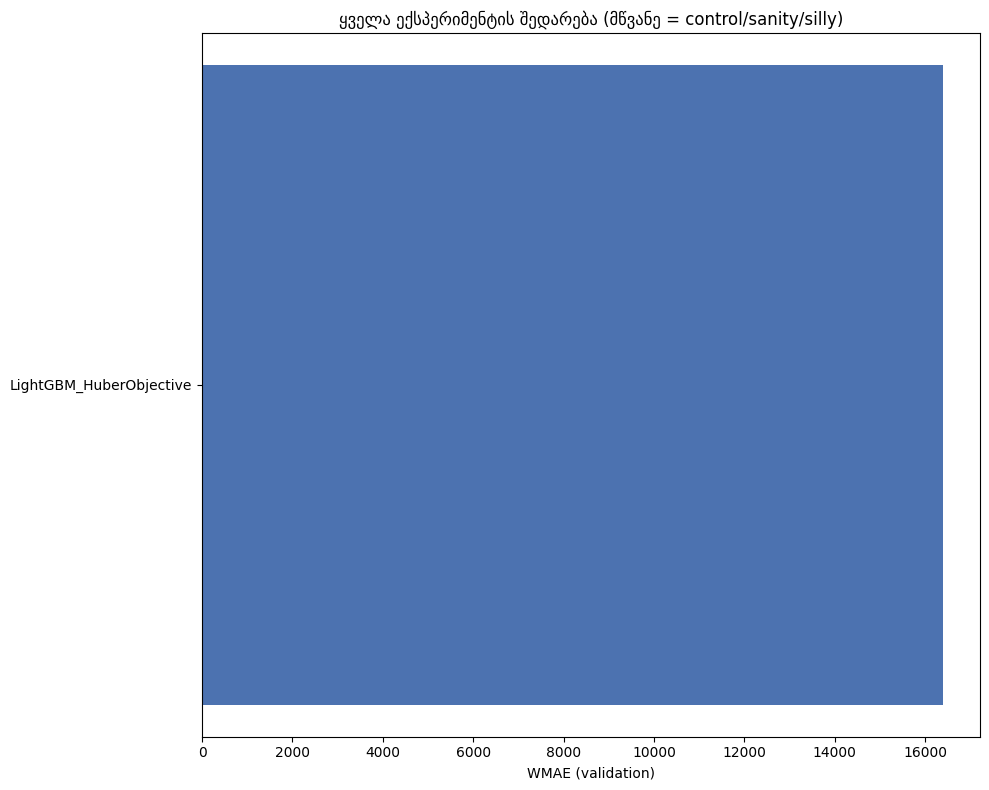

In [32]:
summary_df = pd.DataFrame(experiment_log)[['run', 'wmae_val']].sort_values('wmae_val')
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#55A868' if 'Silly' in r or 'Sanity' in r or 'Control' in r else '#4C72B0' for r in summary_df['run']]
ax.barh(summary_df['run'], summary_df['wmae_val'], color=colors)
ax.set_xlabel('WMAE (validation)')
ax.set_title('ყველა ექსპერიმენტის შედარება (მწვანე = control/sanity/silly)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# საბოლოო მოდელის შერჩევა

In [41]:
candidate_configs = {
    'Run3_LagGroup_default': (full_metrics, dict(learning_rate=0.1, num_boost_round=150)),
    'HPO_best': (best_metrics, best_params),
    'DropWeakFeatures_default': (dropweak_metrics, dict(learning_rate=0.1, num_boost_round=150)),
}
for name, (m, p) in candidate_configs.items():
    print(f"{name}: WMAE_val={m['wmae_val']:.1f}  params={p}")

combo_pipeline = Pipeline([
    ('drop_weak', DropWeakFeatures()),
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(objective='mae', random_state=42, **best_params)),
])
combo_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight_train)
combo_metrics = evaluate(combo_pipeline, X_train, y_train, X_val, y_val)
print("Combo (DropWeak + HPO params): WMAE_val=" + format(combo_metrics["wmae_val"], ".1f"))

Run3_LagGroup_default: WMAE_val=2831.0  params={'learning_rate': 0.1, 'num_boost_round': 150}
HPO_best: WMAE_val=3083.5  params={'learning_rate': 0.05, 'num_boost_round': 300, 'max_depth': 6}
DropWeakFeatures_default: WMAE_val=2746.5  params={'learning_rate': 0.1, 'num_boost_round': 150}
Combo (DropWeak + HPO params): WMAE_val=2944.9


In [42]:
all_candidates = {
    'Run3_default': full_metrics['wmae_val'],
    'HPO_best': best_metrics['wmae_val'],
    'DropWeakFeatures': dropweak_metrics['wmae_val'],
    'Combo_DropWeak_HPO': combo_metrics['wmae_val'],
}
best_candidate_name = min(all_candidates, key=all_candidates.get)
print("საბოლოოდ არჩეული კონფიგურაცია:", best_candidate_name, "WMAE_val =", all_candidates[best_candidate_name])

საბოლოოდ არჩეული კონფიგურაცია: DropWeakFeatures WMAE_val = 2746.538026171567


# საბოლოო მოდელი და Model Registry ში რეგისტრაცია

In [43]:
X_full, y_full = df.drop(columns=['Weekly_Sales']), df['Weekly_Sales']
sample_weight_full = np.where(X_full['IsHoliday'], 5, 1)

# საბოლოო არჩეული pipeline
final_pipeline = Pipeline([
    ('drop_weak', DropWeakFeatures()),
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(objective='mae', random_state=42, **best_params)),
]) if best_candidate_name == 'Combo_DropWeak_HPO' else Pipeline([
    ('drop_weak', DropWeakFeatures()),
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150, objective='mae', random_state=42)),
]) if best_candidate_name == 'DropWeakFeatures' else Pipeline([
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(objective='mae', random_state=42, **best_params)),
]) if best_candidate_name == 'HPO_best' else Pipeline([
    ('lags', LagFeatureBuilder(lag_weeks=(51, 52, 53))),
    ('group_stats', GroupStatsFeatureBuilder()),
    ('temporal', TemporalFeatureBuilder()),
    ('model', LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150)),
])

final_pipeline.fit(X_full, y_full, model__sample_weight=sample_weight_full)

final_metrics = {
    'Run3_default': full_metrics,
    'HPO_best': best_metrics,
    'DropWeakFeatures': dropweak_metrics,
    'Combo_DropWeak_HPO': combo_metrics,
}[best_candidate_name]
print("არჩეული:", best_candidate_name)
print(final_metrics)

არჩეული: DropWeakFeatures
{'mae_train': 1868.702464571675, 'mae_val': 2511.5269887297522, 'wmae_train': np.float64(1983.7021532413305), 'wmae_val': np.float64(2746.538026171567)}


In [44]:
log_run(
    "LightGBM_Final_FullDataFit",
    params={'selected_config': best_candidate_name, 'trained_on': 'full_dataset'},
    metrics=final_metrics,
    pipeline=final_pipeline,
    registered_name="LightGBM_WalmartSales",
)

2026/07/11 05:23:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'LightGBM_WalmartSales'.
2026/07/11 05:23:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LightGBM_WalmartSales, version 1
Created version '1' of model 'LightGBM_WalmartSales'.


LightGBM_Final_FullDataFit -> {'mae_train': 1868.702464571675, 'mae_val': 2511.5269887297522, 'wmae_train': np.float64(1983.7021532413305), 'wmae_val': np.float64(2746.538026171567)}
🏃 View run LightGBM_Final_FullDataFit at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2/runs/046d52d87ae2407599c3fbc58e33e23a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/2
